In [13]:
import numpy as np
import matplotlib.pyplot as plt

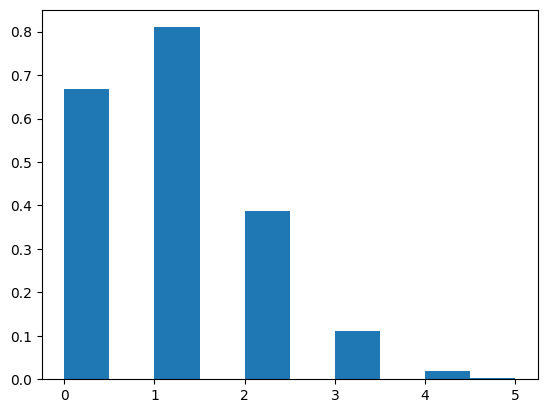

In [20]:
"""
Purpose:
--------
Simulate and visualize a Binomial distribution using random sampling.

Description:
------------
This cell generates random samples from a Binomial distribution defined by:
- n: number of independent trials
- p: probability of success in each trial

It then plots a normalized histogram (density=True) to approximate
the probability mass function (PMF) of the distribution.

Inputs:
-------
n (int)      : Number of trials per experiment
p (float)    : Probability of success in each trial (0 ≤ p ≤ 1)
size (int)   : Number of independent experiments (samples)

Outputs:
--------
- A histogram plot representing the empirical distribution of outcomes

Interpretation:
---------------
- The x-axis represents the number of successes (0 to n)
- The y-axis represents the estimated probability (density)
- As 'size' increases, the histogram converges to the true Binomial PMF
"""

# Number of Bernoulli trials per experiment
n = 10

# Probability of success in each individual trial
p = 0.1

# Total number of independent experiments (samples)
size = 1000

# Generate 'size' samples from a Binomial(n, p) distribution
# Each value represents the number of successes in 'n' trials
binomial_dist = np.random.binomial(n, p, size)

# Plot histogram of the generated samples
# density=True normalizes the histogram so total area = 1 (probability interpretation)
plt.hist(binomial_dist, density=True)

# Display the plot
plt.show()

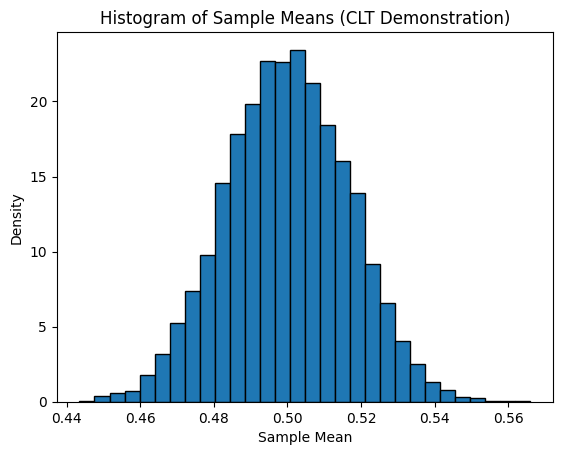

In [21]:
"""
Purpose:
--------
Demonstrate the Central Limit Theorem (CLT) using samples drawn from a Uniform distribution.

Description:
------------
This cell generates multiple samples from a Uniform(a, b) distribution and computes
the mean of each sample. The distribution of these sample means is then visualized.

Even though the original data is uniformly distributed (non-Gaussian), the distribution
of the sample means approaches a Normal (Gaussian) distribution as sample size increases,
which is a direct consequence of the Central Limit Theorem.

Inputs:
-------
num_samples (int)        : Number of independent samples (experiments)
sample_size (int)        : Number of observations per sample
distribution_range (tuple): Lower and upper bounds of the Uniform distribution (a, b)

Outputs:
--------
- Histogram of sample means approximating a Normal distribution

Interpretation:
---------------
- X-axis: Mean value of each sample
- Y-axis: Estimated probability density
- Increasing 'sample_size' improves Gaussian approximation
- Increasing 'num_samples' improves smoothness of the histogram

Theoretical Insight:
-------------------
For Uniform(a, b):
- Mean = (a + b) / 2
- Variance = (b - a)^2 / 12

For sample means:
- Mean remains the same
- Variance reduces to: Var / sample_size
"""

import numpy as np
import matplotlib.pyplot as plt

# Total number of independent samples (how many sample means we compute)
num_samples = 10000

# Number of observations inside each sample
sample_size = 300

# Range (a, b) for Uniform distribution
distribution_range = (0, 1)

# Generate a 2D array:
# Shape = (num_samples, sample_size)
# Each row represents one sample drawn from Uniform(a, b)
samples = np.random.uniform(
    distribution_range[0],
    distribution_range[1],
    (num_samples, sample_size)
)

# Compute mean of each sample (row-wise mean)
# Result: 1D array of length = num_samples
sample_means = np.mean(samples, axis=1)

# Plot histogram of sample means
# bins=30 controls granularity
# density=True normalizes histogram (area = 1)
# edgecolor improves visual clarity
plt.hist(sample_means, bins=30, density=True, edgecolor='black')

# Plot labeling for interpretability
plt.title('Histogram of Sample Means (CLT Demonstration)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')

# Render the plot
plt.show()

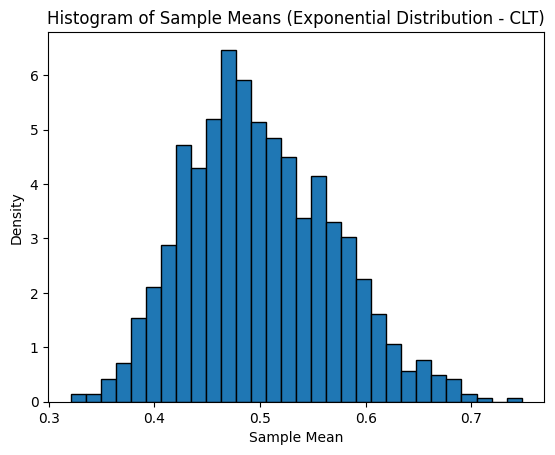

In [22]:
"""
Purpose:
--------
Demonstrate the Central Limit Theorem (CLT) using samples drawn from an Exponential distribution.

Description:
------------
This cell generates multiple samples from an Exponential distribution (which is inherently
right-skewed / non-Gaussian) and computes the mean of each sample.

Despite the original data being highly skewed, the distribution of the sample means tends
toward a Normal (Gaussian) distribution as sample size increases. This behavior is a direct
application of the Central Limit Theorem.

Inputs:
-------
num_samples (int) : Number of independent samples (experiments)
sample_size (int) : Number of observations per sample
lambda_param (float): Rate parameter (λ) of the Exponential distribution

Note:
-----
NumPy uses 'scale = 1/λ' instead of λ directly.

Outputs:
--------
- Histogram of sample means approximating a Normal distribution

Interpretation:
---------------
- X-axis: Mean of each sample
- Y-axis: Estimated probability density
- Original distribution: highly skewed (Exponential)
- Resulting distribution: approximately symmetric (Gaussian-like)

Theoretical Insight:
-------------------
For Exponential(λ):
- Mean = 1 / λ
- Variance = 1 / λ²

For sample means:
- Mean remains: 1 / λ
- Variance reduces to: (1 / λ²) / sample_size
"""

import numpy as np
import matplotlib.pyplot as plt

# Number of independent samples (how many sample means will be computed)
num_samples = 1000

# Number of observations within each sample
sample_size = 50

# Rate parameter (λ) of the exponential distribution
lambda_param = 2

# Generate a 2D array of exponential samples
# Shape = (num_samples, sample_size)
# Each row represents one independent sample
# scale = 1 / λ because NumPy parameterizes exponential using scale
samples = np.random.exponential(
    scale=1 / lambda_param,
    size=(num_samples, sample_size)
)

# Compute mean of each sample (row-wise)
# Result: array of length = num_samples
sample_means = np.mean(samples, axis=1)

# Plot histogram of sample means
# density=True ensures the histogram represents a probability density
# bins=30 controls resolution
plt.hist(sample_means, bins=30, density=True, edgecolor='black')

# Add labels and title for clarity
plt.title('Histogram of Sample Means (Exponential Distribution - CLT)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')

# Display the plot
plt.show()

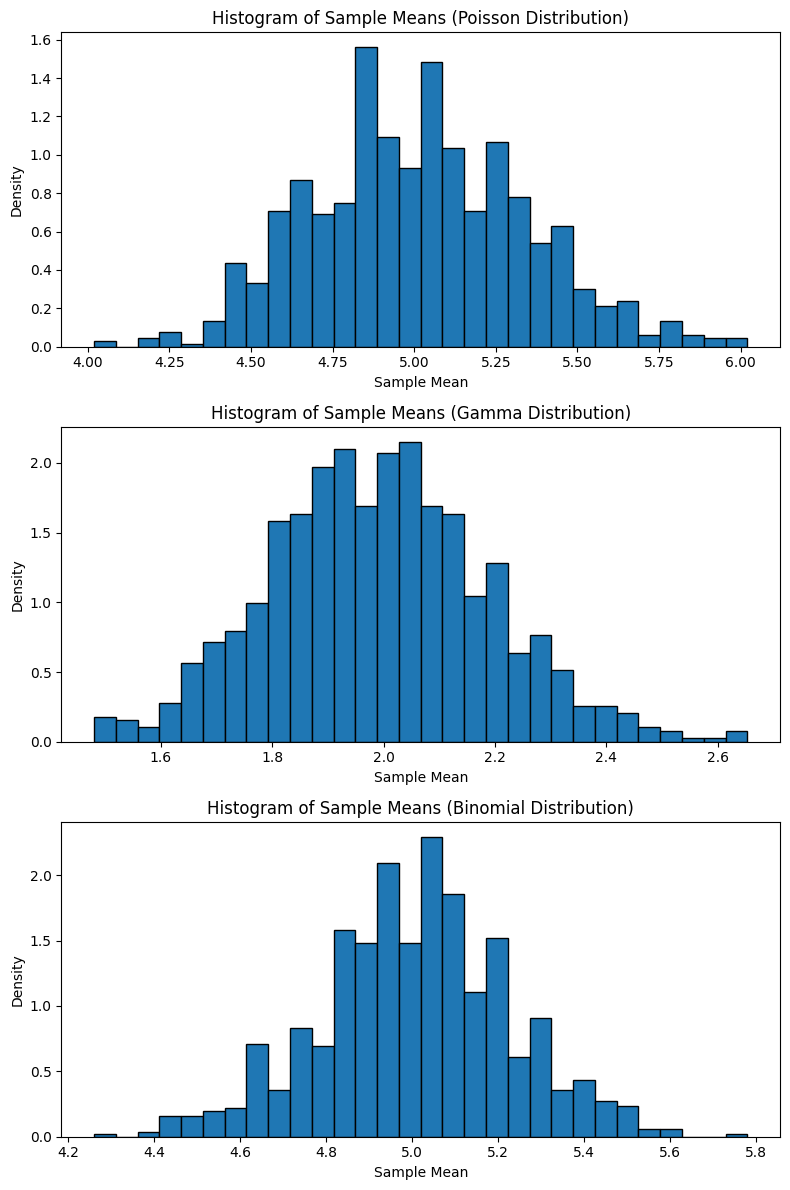

In [23]:
"""
Purpose:
--------
Validate the Central Limit Theorem (CLT) across multiple distributions
(Poisson, Gamma, and Binomial) within a unified experimental setup.

Description:
------------
This cell generates multiple samples from three fundamentally different
distributions (discrete and continuous), computes the mean of each sample,
and visualizes the distribution of those sample means.

Despite differences in the original distributions (skewness, discreteness, etc.),
the sampling distribution of the mean converges toward a Normal distribution,
demonstrating the robustness of the CLT.

Inputs:
-------
num_samples (int) : Number of independent samples (experiments)
sample_size (int) : Number of observations per sample

Poisson:
- poisson_lambda (float): Rate parameter (λ)

Gamma:
- gamma_shape (k)  : Shape parameter
- gamma_scale (θ)  : Scale parameter

Binomial:
- binomial_n (int): Number of trials
- binomial_p (float): Probability of success

Outputs:
--------
- Three vertically stacked histograms showing distributions of sample means

Interpretation:
---------------
- Each subplot represents the sampling distribution of the mean
- All should appear approximately Gaussian despite differing source distributions
- Larger sample_size → stronger normal approximation
- Larger num_samples → smoother histogram

Theoretical Insight:
-------------------
Poisson(λ):
- Mean = λ, Variance = λ

Gamma(k, θ):
- Mean = kθ, Variance = kθ²

Binomial(n, p):
- Mean = np, Variance = np(1-p)

For all:
- Sample mean variance = Original variance / sample_size
"""

import numpy as np
import matplotlib.pyplot as plt

# Number of independent samples (experiments)
num_samples = 1000

# Number of observations per sample
sample_size = 50

# --- Distribution Parameters ---

# Poisson distribution (discrete, right-skewed for small λ)
poisson_lambda = 5

# Gamma distribution (continuous, positively skewed)
gamma_shape = 2
gamma_scale = 1

# Binomial distribution (discrete, symmetric when p ≈ 0.5)
binomial_n = 10
binomial_p = 0.5

# --- Data Generation Phase ---

# Generate samples: each row = one sample
poisson_samples = np.random.poisson(
    lam=poisson_lambda,
    size=(num_samples, sample_size)
)

gamma_samples = np.random.gamma(
    shape=gamma_shape,
    scale=gamma_scale,
    size=(num_samples, sample_size)
)

binomial_samples = np.random.binomial(
    n=binomial_n,
    p=binomial_p,
    size=(num_samples, sample_size)
)

# --- Aggregation Phase: Compute Sample Means ---

# Mean of each sample (row-wise)
poisson_means = np.mean(poisson_samples, axis=1)
gamma_means = np.mean(gamma_samples, axis=1)
binomial_means = np.mean(binomial_samples, axis=1)

# --- Visualization Phase ---

# Create a 3-row subplot layout for side-by-side comparison
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# --- Poisson ---
axs[0].hist(poisson_means, bins=30, density=True, edgecolor='black')
axs[0].set_title('Histogram of Sample Means (Poisson Distribution)')
axs[0].set_xlabel('Sample Mean')
axs[0].set_ylabel('Density')

# --- Gamma ---
axs[1].hist(gamma_means, bins=30, density=True, edgecolor='black')
axs[1].set_title('Histogram of Sample Means (Gamma Distribution)')
axs[1].set_xlabel('Sample Mean')
axs[1].set_ylabel('Density')

# --- Binomial ---
axs[2].hist(binomial_means, bins=30, density=True, edgecolor='black')
axs[2].set_title('Histogram of Sample Means (Binomial Distribution)')
axs[2].set_xlabel('Sample Mean')
axs[2].set_ylabel('Density')

# Optimize spacing to avoid overlap
fig.tight_layout()

# Render all plots
plt.show()

In [24]:
"""
Purpose:
--------
Validate theoretical vs empirical behavior of a Log-Normal distribution,
with emphasis on how sample means behave under the Central Limit Theorem (CLT).

Description:
------------
This cell:
1. Defines a Log-Normal distribution via parameters (mu, sigma) of the underlying Normal.
2. Computes the theoretical mean and variance of the Log-Normal distribution.
3. Generates multiple samples and computes their sample means.
4. Estimates empirical mean and variance from those sample means.
5. Compares theoretical expectations with observed empirical results.

This is effectively a numerical validation pipeline.

Important Distinction:
---------------------
- Theoretical values computed here correspond to the ORIGINAL distribution.
- Empirical values correspond to the DISTRIBUTION OF SAMPLE MEANS.

Under CLT:
----------
- Mean of sample means ≈ theoretical mean
- Variance of sample means ≈ theoretical variance / sample_size

Inputs:
-------
num_samples (int) : Number of independent samples
sample_size (int) : Observations per sample

Log-Normal Parameters:
- mu (float)    : Mean of underlying Normal distribution
- sigma (float) : Standard deviation of underlying Normal

Outputs:
--------
- Printed comparison of theoretical vs empirical mean and variance

Interpretation:
---------------
- Means should align closely
- Variance of sample means should be significantly smaller
- Any mismatch in variance is expected unless scaled by sample_size

Theoretical Insight:
-------------------
If X ~ LogNormal(mu, sigma):

Mean:
    E[X] = exp(mu + sigma^2 / 2)

Variance:
    Var(X) = (exp(sigma^2) - 1) * exp(2mu + sigma^2)

For sample means:
    Var(mean) = Var(X) / sample_size
"""

import numpy as np

# Number of independent samples
num_samples = 10000

# Number of observations per sample
sample_size = 50

# Log-Normal parameters (applied to underlying Normal distribution)
mu = 0.5
sigma = 0.7

# --- Theoretical Calculations (Original Distribution) ---

# Expected value of Log-Normal distribution
theoretical_mean = np.exp(mu + (sigma ** 2) / 2)

# Variance of Log-Normal distribution
theoretical_variance = (np.exp(sigma ** 2) - 1) * np.exp(2 * mu + sigma ** 2)

# --- Data Generation Phase ---

# Generate samples:
# Shape = (num_samples, sample_size)
# Each row = one sample from Log-Normal distribution
samples = np.random.lognormal(
    mean=mu,
    sigma=sigma,
    size=(num_samples, sample_size)
)

# --- Aggregation Phase ---

# Compute sample mean for each sample (row-wise)
sample_means = np.mean(samples, axis=1)

# --- Empirical Estimation ---

# Mean of the sample means (should approximate theoretical_mean)
empirical_mean = np.mean(sample_means)

# Variance of sample means (should approximate theoretical_variance / sample_size)
empirical_variance = np.var(sample_means)

# --- Reporting Phase ---

# Display comparison results
print(f"Theoretical mean: {theoretical_mean:.4f}")
print(f"Empirical mean: {empirical_mean:.4f}")
print(f"\n")
print(f"Theoretical variance: {theoretical_variance:.4f}")
print(f"Empirical variance: {empirical_variance:.4f}")

Theoretical mean: 2.1064
Empirical mean: 2.1062


Theoretical variance: 2.8056
Empirical variance: 0.0563


# **Case Study 1**

In [25]:
"""
Purpose:
--------
Estimate the average salary and construct a 95% confidence interval
using repeated sampling from a synthetic population.

Description:
------------
This cell:
1. Simulates a population of salaries using a Log-Normal distribution
   (appropriate for income data due to right skew).
2. Draws multiple random samples from this population.
3. Computes the sample mean for each sample.
4. Estimates the overall mean and constructs a confidence interval.

Important Clarification:
------------------------
- You are computing the mean of sample means (which approximates population mean).
- HOWEVER, your standard error is based on variability across sample means,
  not within a single sample.

This is a "meta-sampling" approach (sampling distributions), not the
standard textbook CI based on a single sample.

Inputs:
-------
population_size (int): Total synthetic population size
sample_size (int)    : Number of observations per sample
num_samples (int)    : Number of repeated samples

Outputs:
--------
- Estimated average salary
- 95% confidence interval

Interpretation:
---------------
- The interval reflects uncertainty in estimating the population mean
- Increasing sample_size → tighter interval
- Increasing num_samples → more stable estimate of sampling distribution

Theoretical Context:
-------------------
Standard CI formula (single sample):
    mean ± z * (s / sqrt(n))

Your approach:
    Uses distribution of sample means directly (empirical SE)
"""

import numpy as np

# --- Configuration ---

# Total number of individuals in synthetic population
population_size = 100000

# Number of observations per sample
sample_size = 50

# Number of repeated samples
num_samples = 100

# --- Data Generation ---

# Set seed for reproducibility (ensures consistent results across runs)
np.random.seed(42)

# Generate population salaries using Log-Normal distribution
# Mean and sigma chosen to simulate realistic right-skewed income data
population_salaries = np.random.lognormal(
    mean=4.5,
    sigma=0.8,
    size=population_size
)

# --- Sampling Phase ---

# Containers for storing results
sample_means = []
sample_std_devs = []

# Perform repeated random sampling
for _ in range(num_samples):
    # Draw a random sample (with replacement by default)
    sample_salaries = np.random.choice(
        population_salaries,
        size=sample_size
    )

    # Compute statistics for this sample
    sample_means.append(np.mean(sample_salaries))
    sample_std_devs.append(np.std(sample_salaries))

# --- Aggregation Phase ---

# Mean of sample means (estimate of population mean)
average_sample_means = np.mean(sample_means)

# Standard error based on variability across sample means
# NOTE: This is NOT the same as s / sqrt(n) from a single sample
standard_error = np.std(sample_means) / np.sqrt(num_samples)

# --- Confidence Interval Calculation ---

# Z-score for 95% confidence level (approximation using Normal distribution)
margin_of_error = 1.96 * standard_error

# Lower and upper bounds of CI
lower_limit = average_sample_means - margin_of_error
upper_limit = average_sample_means + margin_of_error

# --- Reporting ---

print(f"Estimated average salary (in thousands): {average_sample_means:.2f}")
print(f"95% confidence interval (in thousands): ({lower_limit:.2f}, {upper_limit:.2f})")

Estimated average salary (in thousands): 124.74
95% confidence interval (in thousands): (121.23, 128.26)
